# 🧠 Option Data Retrieval and Preprocessing

In this notebook, we fetch real-time **options data** for two selected stocks using the [Yahoo Finance API](https://pypi.org/project/yfinance/).  
The goal is to obtain the **current stock price**, **strike prices**, and **bid/ask values** for both *call* and *put* options, filtered to include only active contracts (with nonzero ask prices).  

---

### 💡 Overview

This script performs the following steps:

1. **Fetch market data** for each selected ticker symbol using `yfinance.Ticker`.
2. **List all available expiration dates** and allow the user to select one interactively.
3. **Extract option chain data** (calls and puts) for the chosen expiration.
4. **Filter out illiquid options** (entries with zero ask prices).
5. **Store the processed data** for both stocks into structured Python dictionaries.

---

### 📘 Notes

- The function `fetch_options_data(ticker)` automatically downloads and cleans the option chain.
- All computations are performed in real time, so an active internet connection is required.
- The retrieved datasets will be used in later sections for **optimization**, **visualization**, and **portfolio construction**.

---

### ⚙️ Dependencies

This notebook uses the following Python libraries:
```bash
numpy, yfinance, scipy, prettytable, matplotlib


=== Option Data Loader ===
Enter the first ticker symbol (e.g., AAPL): HTZ
Enter the second ticker symbol (e.g., MSFT): AAPL

Common expiration dates for HTZ and AAPL:
1. 2025-11-14
2. 2025-11-21
3. 2025-11-28
4. 2025-12-05
5. 2025-12-12
6. 2025-12-19
7. 2026-01-16
8. 2026-03-20
9. 2026-06-18
10. 2026-12-18
11. 2027-01-15
12. 2028-01-21

Select an expiration date (1-12): 3

You selected expiration date: 2025-11-28

HTZ — Current Price: $6.58
AAPL — Current Price: $268.47
+-------+---------------+--------------+---------------------+
| Stock | Calls (count) | Puts (count) | Selected Expiration |
+-------+---------------+--------------+---------------------+
|  HTZ  |       14      |      10      |      2025-11-28     |
|  AAPL |       44      |      38      |      2025-11-28     |
+-------+---------------+--------------+---------------------+


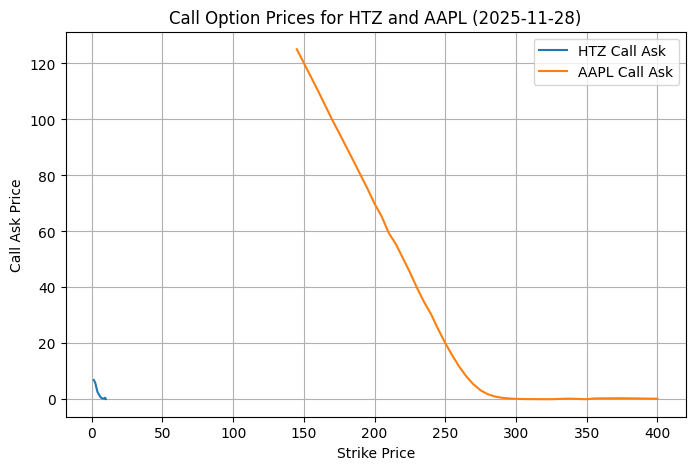


✅ Data successfully loaded and assigned for both assets.


In [20]:
# ====================================================================
# 📈 Option Chain Data Loader for Two Stocks with Common Expiration Dates
# ====================================================================

import numpy as np
import yfinance as yf
from prettytable import PrettyTable
import matplotlib.pyplot as plt

# --------------------------------------------------------------------
# 1. Function: Fetch option chain data for a single ticker and given expiration
# --------------------------------------------------------------------
def fetch_options_data(ticker, expiration_date):
    """
    Downloads and filters options data (calls & puts) for a specific ticker
    and expiration date from Yahoo Finance.
    """
    stock = yf.Ticker(ticker)
    stock_value = stock.history(period='1d')['Close'].iloc[-1]  # Current stock price
    options_chain = stock.option_chain(expiration_date)         # Option chain data

    # Extract call and put data
    call_strikes = options_chain.calls['strike'].to_numpy()
    put_strikes = options_chain.puts['strike'].to_numpy()
    call_ask = options_chain.calls['ask'].to_numpy()
    call_bid = options_chain.calls['bid'].to_numpy()
    put_ask = options_chain.puts['ask'].to_numpy()
    put_bid = options_chain.puts['bid'].to_numpy()

    # Filter out illiquid options (ask == 0)
    valid_call_mask = call_ask > 0
    call_strikes = call_strikes[valid_call_mask]
    call_ask = call_ask[valid_call_mask]
    call_bid = call_bid[valid_call_mask]

    valid_put_mask = put_ask > 0
    put_strikes = put_strikes[valid_put_mask]
    put_ask = put_ask[valid_put_mask]
    put_bid = put_bid[valid_put_mask]

    return {
        'stock_value': stock_value,
        'call_strikes': call_strikes,
        'put_strikes': put_strikes,
        'call_ask': call_ask,
        'call_bid': call_bid,
        'put_ask': put_ask,
        'put_bid': put_bid
    }

# --------------------------------------------------------------------
# 2. User input: Two tickers
# --------------------------------------------------------------------
print("=== Option Data Loader ===")
ticker1 = input("Enter the first ticker symbol (e.g., AAPL): ").strip().upper()
ticker2 = input("Enter the second ticker symbol (e.g., MSFT): ").strip().upper()

# --------------------------------------------------------------------
# 3. Retrieve available expiration dates for both tickers
# --------------------------------------------------------------------
stock1 = yf.Ticker(ticker1)
stock2 = yf.Ticker(ticker2)

expirations1 = stock1.options
expirations2 = stock2.options

# Find common expiration dates between the two stocks
common_expirations = sorted(list(set(expirations1).intersection(set(expirations2))))

if not common_expirations:
    raise ValueError(f"No common expiration dates found between {ticker1} and {ticker2}.")

# --------------------------------------------------------------------
# 4. Display common expirations and allow user to choose one
# --------------------------------------------------------------------
print(f"\nCommon expiration dates for {ticker1} and {ticker2}:")
for i, date in enumerate(common_expirations):
    print(f"{i+1}. {date}")

choice = int(input(f"\nSelect an expiration date (1-{len(common_expirations)}): ")) - 1
selected_expiration = common_expirations[choice]

print(f"\nYou selected expiration date: {selected_expiration}")

# --------------------------------------------------------------------
# 5. Fetch option data for both tickers using the selected expiration date
# --------------------------------------------------------------------
data1 = fetch_options_data(ticker1, selected_expiration)
data2 = fetch_options_data(ticker2, selected_expiration)

# --------------------------------------------------------------------
# 6. Display summary of retrieved data
# --------------------------------------------------------------------
print(f"\n{ticker1} — Current Price: ${data1['stock_value']:.2f}")
print(f"{ticker2} — Current Price: ${data2['stock_value']:.2f}")

t = PrettyTable(['Stock', 'Calls (count)', 'Puts (count)', 'Selected Expiration'])
t.add_row([ticker1, len(data1['call_strikes']), len(data1['put_strikes']), selected_expiration])
t.add_row([ticker2, len(data2['call_strikes']), len(data2['put_strikes']), selected_expiration])
print(t)

# --------------------------------------------------------------------
# 7. (Optional) Quick visualization of Call Ask Prices vs Strike
# --------------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(data1['call_strikes'], data1['call_ask'], label=f'{ticker1} Call Ask')
plt.plot(data2['call_strikes'], data2['call_ask'], label=f'{ticker2} Call Ask')
plt.xlabel('Strike Price')
plt.ylabel('Call Ask Price')
plt.title(f'Call Option Prices for {ticker1} and {ticker2} ({selected_expiration})')
plt.legend()
plt.grid(True)
plt.show()

# --- Assign key option data for both assets ---
stock_value1 = data1['stock_value']
call_strikes1 = data1['call_strikes']
put_strikes1 = data1['put_strikes']
call_ask1 = data1['call_ask']
call_bid1 = data1['call_bid']
put_ask1 = data1['put_ask']
put_bid1 = data1['put_bid']

stock_value2 = data2['stock_value']
call_strikes2 = data2['call_strikes']
put_strikes2 = data2['put_strikes']
call_ask2 = data2['call_ask']
call_bid2 = data2['call_bid']
put_ask2 = data2['put_ask']
put_bid2 = data2['put_bid']

print("\n✅ Data successfully loaded and assigned for both assets.")



# 🎯 Future Price Scenarios Input

In this section, the user manually defines a set of **future stock price scenarios** for the two selected assets.  
Each scenario represents a possible combination of the **future prices** \( K \) (for stock 1) and \( L \) (for stock 2).  
These scenarios will later be used in the **portfolio optimization** or **options payoff analysis** process.

---

### 🧩 Steps

1. The script first displays the **current market prices** of both stocks:
   $$
   S_1 = \text{Current price of stock 1}, \quad S_2 = \text{Current price of stock 2}
   $$
2. The user specifies how many **scenarios** they want to create.
3. For each scenario $ i $, the user enters a pair of positive numbers:
   $$
   (K_i, L_i)
   $$
   where:
   - $ K_i $: possible future price of stock 1  
   - $ L_i $: possible future price of stock 2
4. The data are stored in a NumPy array `KKmax` for later computation.

---

### 📘 Notes

- All input values must be **positive** real numbers.
- The number of scenarios must be **at least one**.
- This manual input allows flexibility for **custom market assumptions** and **what-if simulations**.

---

$$
\textbf{Next Step:} \quad \text{Run the following cell to input and display all future price scenarios.}
$$


In [25]:
import numpy as np

# Display current stock prices
print("\n========================================")
print("Current stock prices:")
print(f"Stock 1 ({ticker1}): {stock_value1:.2f}")
print(f"Stock 2 ({ticker2}): {stock_value2:.2f}")
print("========================================\n")

# Ask the user to input KKmax scenarios
KKmax = []

while True:
    try:
        n_scenarios = int(input("How many future price scenarios would you like to enter? "))
        if n_scenarios > 0:
            break
        else:
            print("The number must be at least 1.")
    except ValueError:
        print("Please enter a valid integer.")

for i in range(n_scenarios):
    while True:
        try:
            user_input = input(f"Enter the future prices for scenario {i+1} (format: K L): ")
            K_str, L_str = user_input.split()
            K = float(K_str)
            L = float(L_str)
            if K > 0 and L > 0:
                KKmax.append([K, L])
                break
            else:
                print("Values must be positive.")
        except ValueError:
            print("Invalid format. Please enter two numbers separated by a space.")

# Convert to numpy array
KKmax = np.array(KKmax)

print("\n✅ The scenarios you entered:")
print(KKmax)



Current stock prices:
Stock 1 (HTZ): 6.58
Stock 2 (AAPL): 268.47

How many future price scenarios would you like to enter? 1
Enter the future prices for scenario 1 (format: K L): 2 500

✅ The scenarios you entered:
[[  2. 500.]]


# ⚙️ Main Optimization Model — Portfolio and Options Allocation

In this section, we define and solve a **Mixed-Integer Linear Programming (MILP)** problem to determine the **optimal portfolio allocation** involving two assets and their corresponding **call** and **put options**.

---

### 🧩 Model Overview

The goal is to find the portfolio vector $$\mathbf{x}$$ that **maximizes the minimum payoff** across all market scenarios, while satisfying investment, position, and risk constraints:

$$
\begin{aligned}
\text{maximize} \quad & \min_i \; t_i \\
\text{subject to:} \quad & A\mathbf{x} \leq \mathbf{b}, \\
& \mathbf{l_b} \leq \mathbf{x} \leq \mathbf{u_b}, \\
& x_i \in \mathbb{Z} \;\; \text{for selected variables.}
\end{aligned}
$$

---

### 🧮 Key Components

| Symbol | Description |
|:------:|:-------------|
| $$D$$ | Maximum acceptable loss |
| $$V$$ | Total investment capital |
| $$P(x, y)$$ | Payoff function for the two-asset system |
| $$\mathbf{A}, \mathbf{b}$$ | Linear constraint matrix and vector |
| $$\mathbf{l_b}, \mathbf{u_b}$$ | Lower and upper bounds |
| $$\mathbf{f}$$ | Objective function coefficients |
| $$t_i$$ | Auxiliary variables for each scenario |

---

### 💼 Decision Variables

| Variable Type | Description |
|---------------|-------------|
| $$x_1, x_2$$ | Number of shares (long/short) for stock 1 and 2 |
| $$c_i^{+}, c_i^{-}$$ | Quantities of call options (buy/sell) |
| $$p_i^{+}, p_i^{-}$$ | Quantities of put options (buy/sell) |
| $$t_i$$ | Payoff variables for each scenario $$(K_i, L_i)$$ |

---

### 🔒 Constraints

1. **Capital constraint:**

   $$
   \mathbf{a}_{\text{inv}}^\top \mathbf{x} \leq V
   $$

2. **Option limits:**  
   Bounds on the number of call/put contracts that can be bought or sold.

3. **Stock position limits:**

   $$
   -N_{\text{sell}}^{(s)} \leq x_j \leq N_{\text{buy}}^{(s)}, \quad j = 1,2
   $$

4. **Scenario constraints:**  
   For each price scenario $$(K_i, L_i)$$,

   $$
   P(K_i, L_i) - t_i \geq -V
   $$

---

### 🧠 Solver Details

The optimization is solved with **`scipy.optimize.milp`**, which supports both integer and continuous decision variables under linear constraints:

```python
result = milp(c=f,
              constraints=constraints,
              bounds=bounds,
              integrality=integrality)


In [26]:
# The main part of the code.

from scipy.optimize import milp, LinearConstraint, Bounds

# ====================================================================
# 2. Definition of Constraints & Remaining Parameters
# ====================================================================

# Maximum acceptable loss
D = 1000

# Investment amount
V = 1000
# Constraints
max_number_of_total_call_options_to_buy = 800
max_number_of_total_put_options_to_buy = 800
max_number_of_total_call_options_to_sell = 800
max_number_of_total_put_options_to_sell = 800

max_number_of_call_options_to_buy = 2
max_number_of_put_options_to_buy = 2
max_number_of_call_options_to_sell = 2
max_number_of_put_options_to_sell = 2

max_number_of_shares_to_buy = 100
max_number_of_shares_to_sell = 100

number_of_Kmaxes = KKmax.shape[0]




# ====================================================================
# 3. Payoff Function for 2 assets
# ====================================================================

def P(x, y):
    row = [x, y]  # Long/short shares for asset 1 and 2

    # Call options for asset 1
    for K in call_strikes1:
        row.append(max(x - K, 0))     # Call Buy


    for K in call_strikes1:
        row.append(-max(x - K, 0))    # Call Sell


    # Put options for asset 1
    for L in put_strikes1:
        row.append(max(L - x, 0))     # Put Buy

    for L in put_strikes1:
        row.append(-max(L - x, 0))    # Put Sell



    # Call options for asset 2
    for K in call_strikes2:
        row.append(max(y - K, 0))     # Call Buy
    for K in call_strikes2:
        row.append(-max(y - K, 0))    # Call Sell

    # Put options for asset 2
    for L in put_strikes2:
        row.append(max(L - y, 0))     # Put Buy
    for L in put_strikes2:
        row.append(-max(L - y, 0))    # Put Sell

    # === NEW: Add zeros equal to KKmax.shape[0] ===
    number_of_Kmaxes = KKmax.shape[0]
    row += [0] * number_of_Kmaxes

    return np.array(row)



#####################################################################
# Construction of matrices A and b
#####################################################################
constraint_points = [(0, 0)]

combined1 = np.concatenate((call_strikes1, put_strikes1))
unique_combined1 = np.unique(combined1)

combined2 = np.concatenate((call_strikes2, put_strikes2))
unique_combined2 = np.unique(combined2)

max_element_strikes1=np.max(unique_combined1)
unique_combined1=np.append(unique_combined1,max_element_strikes1+1)

max_element_strikes2=np.max(unique_combined2)
unique_combined2=np.append(unique_combined2,max_element_strikes2+1)


# Add (K_i, 0)
for K in unique_combined1:
    constraint_points.append((K, 0))


# Add (0, L_j)
for L in unique_combined2:
    constraint_points.append((0, L))


# Add (K_i, L_j)
for K in unique_combined1:
    for L in unique_combined2:
        constraint_points.append((K, L))




# Convert to matrix
AA_list = []
b_list = []

for point in constraint_points:
    AA_list.append(P(point[0], point[1]))
    b_list.append(V-D)

# Convert to numpy arrays
AA = -np.array(AA_list)
b = -np.array(b_list)

####################################################################################

#######################################################
# Placement of derivative for stock 1
#######################################################
# Create a zero vector
new_row = np.zeros(AA.shape[1])

# Stock 1 position (long/short)
new_row[0] = -1  # Long/short shares for asset 1

offset = 2  # start after the two asset positions

# Call Ask 1
for i in range(len(call_strikes1)):
    new_row[offset + i] = -1

offset += len(call_strikes1)

# Call Bid 1
for i in range(len(call_strikes1)):
    new_row[offset + i] = 1

# Remaining positions stay 0

# Add to matrix AA
AA = np.vstack([AA, new_row])

# Corresponding b (depends on desired constraint)
b = np.append(b, 0)  # e.g. new_row · x <= 0

#######################################################
# Placement of derivative for stock 2
#######################################################
# Create a new vector for stock 2
new_row_2 = np.zeros(AA.shape[1])

# Stock 2 position (long/short)
new_row_2[1] = -1  # Second element: asset 2

offset = 2  # start after the two asset positions

# Call Ask 1
offset += len(call_strikes1)

# Call Bid 1
offset += len(call_strikes1)

# Put Ask 1
offset += len(put_strikes1)

# Put Bid 1
offset += len(put_strikes1)

# === Call Ask 2 ===
num_call_strikes2 = len(call_strikes2)
for i in range(num_call_strikes2):
    new_row_2[offset + i] = -1

offset += num_call_strikes2

# === Call Bid 2 ===
for i in range(num_call_strikes2):
    new_row_2[offset + i] = 1

# Remaining positions stay 0

# Add to matrix AA
AA = np.vstack([AA, new_row_2])

# Corresponding b (e.g. ≤ 0)
b = np.append(b, 0)
#################################################################################################


###################################################################################################
# Here we add the rows related to KKmaxes. That is, P(KKmax_i,KKmax_j) \geq D_ij
number_of_Kmaxes = KKmax.shape[0]

for idx, point in enumerate(KKmax):
    x = point[0]
    y = point[1]

    # Calculate the payoff vector (includes [0]*number_of_Kmaxes at the end)
    payoff_vector = P(x, y)

    # Create a new vector to modify the last number_of_Kmaxes elements
    new_row = payoff_vector.copy()

    # Zero out the last number_of_Kmaxes elements
    new_row[-number_of_Kmaxes:] = 0

    # Set 1 only at the position corresponding to the current scenario
    new_row[-number_of_Kmaxes + idx] = -1

    # Add the row to AA (e.g. Payoff >= t)
    AA = np.vstack([AA, -new_row])
    b = np.append(b, -V)  # i.e. new_row · x <= -V
####################################################################################################



# Add total investment constraint
Aeq = np.concatenate((
    [stock_value1, stock_value2],
    call_ask1, -call_bid1,
    put_ask1, -put_bid1,
    call_ask2, -call_bid2,
    put_ask2, -put_bid2
))
Aeq = np.append(Aeq, np.zeros(number_of_Kmaxes))
AA = np.vstack([AA, Aeq])
b = np.append(b, V)

# Add max number of options constraints
A_call_buy = np.zeros(AA.shape[1])
A_call_sell = np.zeros(AA.shape[1])
A_put_buy = np.zeros(AA.shape[1])
A_put_sell = np.zeros(AA.shape[1])

offset = 2  # first two are shares

for i in range(len(call_strikes1)):
    A_call_buy[offset + i] = 1
for i in range(len(call_strikes1), 2 * len(call_strikes1)):
    A_call_sell[offset + i] = 1
for i in range(2 * len(call_strikes1), 2 * len(call_strikes1) + len(put_strikes1)):
    A_put_buy[offset + i] = 1
for i in range(2 * len(call_strikes1) + len(put_strikes1),
               2 * len(call_strikes1) + 2 * len(put_strikes1)):
    A_put_sell[offset + i] = 1

for i in range(len(call_strikes2)):
    A_call_buy[offset + 2 * len(call_strikes1) + 2 * len(put_strikes1) + i] = 1
for i in range(len(call_strikes2), 2 * len(call_strikes2)):
    A_call_sell[offset + 2 * len(call_strikes1) + 2 * len(put_strikes1) + i] = 1
for i in range(2 * len(call_strikes2),
               2 * len(call_strikes2) + len(put_strikes2)):
    A_put_buy[offset + 2 * len(call_strikes1) + 2 * len(put_strikes1) + i] = 1
for i in range(2 * len(call_strikes2) + len(put_strikes2),
               2 * len(call_strikes2) + 2 * len(put_strikes2)):
    A_put_sell[offset + 2 * len(call_strikes1) + 2 * len(put_strikes1) + i] = 1

AA = np.vstack([AA, A_call_buy, A_call_sell, A_put_buy, A_put_sell])
b = np.append(b, [max_number_of_total_call_options_to_buy,
                  max_number_of_total_call_options_to_sell,
                  max_number_of_total_put_options_to_buy,
                  max_number_of_total_put_options_to_sell])

# Set bounds
lb = np.zeros(AA.shape[1])
ub = np.full(AA.shape[1], np.inf)


# Initialize bounds
n_vars = AA.shape[1]  # Total number of variables
lb = np.zeros(n_vars)
ub = np.full(n_vars, np.inf)

# Position of stock 1 (can be fractional)
lb[0] = -max_number_of_shares_to_sell
ub[0] = max_number_of_shares_to_buy

# Position of stock 2
lb[1] = -max_number_of_shares_to_sell
ub[1] = max_number_of_shares_to_buy

offset = 2  # start after stocks

# Asset 1: Calls & Puts
for i in range(len(call_strikes1)):
    ub[offset + i] = max_number_of_call_options_to_buy
offset += len(call_strikes1)

for i in range(len(call_strikes1)):
    ub[offset + i] = max_number_of_call_options_to_sell
offset += len(call_strikes1)

for i in range(len(put_strikes1)):
    ub[offset + i] = max_number_of_put_options_to_buy
offset += len(put_strikes1)

for i in range(len(put_strikes1)):
    ub[offset + i] = max_number_of_put_options_to_sell
offset += len(put_strikes1)

# Asset 2: Calls & Puts
for i in range(len(call_strikes2)):
    ub[offset + i] = max_number_of_call_options_to_buy
offset += len(call_strikes2)

for i in range(len(call_strikes2)):
    ub[offset + i] = max_number_of_call_options_to_sell
offset += len(call_strikes2)

for i in range(len(put_strikes2)):
    ub[offset + i] = max_number_of_put_options_to_buy
offset += len(put_strikes2)

for i in range(len(put_strikes2)):
    ub[offset + i] = max_number_of_put_options_to_sell
offset += len(put_strikes2)

# Now we are at the beginning of the KKmax variables
# Set lb = 0 and ub = inf for them
for i in range(offset, offset + number_of_Kmaxes):
    lb[i] = 0

bl = -np.inf * np.ones_like(b)
bl[-5] = V

# Integrality
integrality = np.ones(AA.shape[1])
integrality[0] = 0  # Shares can be fractional
integrality[1]=0


# Objective function
f = np.zeros(AA.shape[1])
f[-number_of_Kmaxes:] = -1

# Solve
constraints = LinearConstraint(AA, bl, b)
bounds = Bounds(lb, ub)

result = milp(c=f, constraints=constraints, integrality=integrality, bounds=bounds)
print(result)


        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -17016.0
              x: [-2.360e+01 -4.075e+00 ...  2.000e+00  1.702e+04]
 mip_node_count: 1
 mip_dual_bound: -17016.0
        mip_gap: 0.0


# 📊 Results and Profit Surface Visualization

This section analyzes the **optimized portfolio solution** obtained from the MILP model and visualizes its **profit surface** as a function of the two underlying stock prices.

---

### 🧾 Step 1 — Display of Results

The optimization output vector `x` is decomposed to show:

| Component | Description |
|------------|-------------|
| `x[0]`, `x[1]` | Number of shares for stock 1 and stock 2 |
| Option variables | Quantities of call and put options bought or sold |
| `t_i` | Auxiliary payoff variables corresponding to each scenario |

Two summary tables are displayed:
1. **Stock Positions Table** – current holdings and invested amounts.  
2. **Options Table** – positions for all call/put contracts (buy/sell) that have non-zero allocations.

The total capital used is verified via the constraint:

$$
\mathbf{a}_{\text{inv}}^\top \mathbf{x} = V
$$

---

### 🧮 Step 2 — Profit Function

The profit (or payoff) of the optimized portfolio for given stock prices \(x_1, x_2\) is computed as:

$$
\Pi(x_1, x_2) =
x_1 S_1 + x_2 S_2
+ \sum_i \text{Call}^{(1)}_i(x_1)
+ \sum_i \text{Put}^{(1)}_i(x_1)
+ \sum_j \text{Call}^{(2)}_j(x_2)
+ \sum_j \text{Put}^{(2)}_j(x_2)
- V
$$

where each term \( \text{Call}^{(1)}_i(x_1) = \max(x_1 - K_i, 0) \) and  
\( \text{Put}^{(1)}_i(x_1) = \max(K_i - x_1, 0) \) represents the option payoff at strike \( K_i \).

---

### 🌐 Step 3 — 3D Profit Surface

A 3D surface plot is generated for the range:

$$
x_1 \in [0, 2.1S_1], \quad
x_2 \in [0, 2.1S_2]
$$

The surface shows the **portfolio profit** as both assets’ prices vary simultaneously.

Each red point on the plot corresponds to a **user-defined future price scenario** \((K_i, L_i)\), annotated with the computed profit value.

---

### 🧭 Step 4 — Identifying Minimum Profit

Finally, the algorithm locates the **minimum value** of the profit surface:

$$
\min_{x_1, x_2} \; \Pi(x_1, x_2)
$$

and prints both the coordinates \((x_1, x_2)\) and the corresponding minimal profit, which represent the **worst-case outcome** among the simulated states.

---

$$
\boxed{
\textbf{Next Step: Run the following cell to display tables, plot the 3D profit surface, and identify the worst-case scenario.}
}
$$


+---------+--------+---------------------+-------------------+---------------------+
|  Asset  | Ticker |        Shares       |       Price       |        Amount       |
+---------+--------+---------------------+-------------------+---------------------+
| Stock 1 |  HTZ   | -23.595302468213358 | 6.579999923706055 | -155.25708844066517 |
| Stock 2 |  AAPL  |  -4.074618790127146 | 268.4700012207031 | -1093.9129115593348 |
+---------+--------+---------------------+-------------------+---------------------+
+---------------+--------+--------+--------+
|      Type     | Strike | Number | Price  |
+---------------+--------+--------+--------+
|  Call HTZ Buy |  4.0   |   2    |  2.75  |
|  Call HTZ Buy |  4.5   |   2    |  2.25  |
|  Call HTZ Buy |  5.0   |   2    |  1.8   |
|  Call HTZ Buy |  5.5   |   2    |  1.4   |
|  Call HTZ Buy |  6.0   |   2    |  0.95  |
|  Call HTZ Buy |  6.5   |   2    |  0.65  |
|  Call HTZ Buy |  7.0   |   2    |  0.45  |
|  Call HTZ Buy |  8.0   |   2    |  0.2

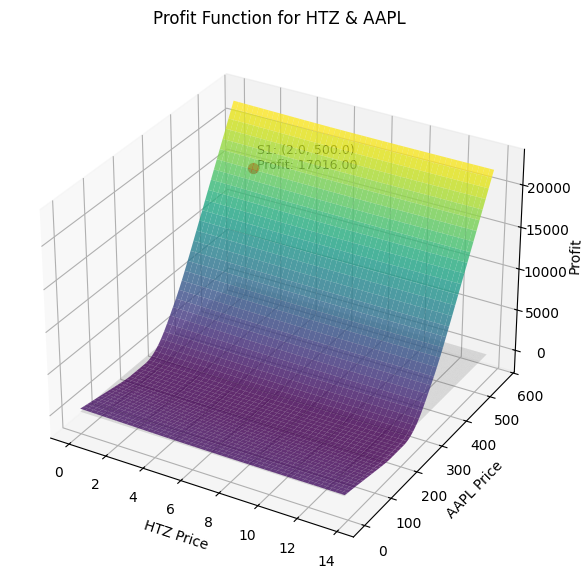

The minimum value of Z is: -999.6521571339715
It occurs at the point (X1, X2): (9.99895465793322, 223.814940716154)


In [27]:
# ====================================================================
# 5. Results
# ====================================================================

x = result.x


# Print results table
t = PrettyTable(['Asset', 'Ticker', 'Shares', 'Price', 'Amount'])
t.add_row(['Stock 1', ticker1, x[0], stock_value1, x[0] * stock_value1])
t.add_row(['Stock 2', ticker2, x[1], stock_value2, x[1] * stock_value2])
print(t)

tt = PrettyTable(['Type', 'Strike', 'Number', 'Price'])

offset = 2

# Asset 1: Call Options - Buy
for i, K in enumerate(call_strikes1):
    if x[offset + i] > 0.1:
        tt.add_row([f'Call {ticker1} Buy', K, round(x[offset + i]), call_ask1[i]])

offset += len(call_strikes1)

# Asset 1: Call Options - Sell
for i, K in enumerate(call_strikes1):
    if x[offset + i] > 0.1:
        tt.add_row([f'Call {ticker1} Sell', K, -round(x[offset + i]), call_bid1[i]])

offset += len(call_strikes1)

# Asset 1: Put Options - Buy
for i, L in enumerate(put_strikes1):
    if x[offset + i] > 0.1:
        tt.add_row([f'Put {ticker1} Buy', L, round(x[offset + i]), put_ask1[i]])

offset += len(put_strikes1)

# Asset 1: Put Options - Sell
for i, L in enumerate(put_strikes1):
    if x[offset + i] > 0.1:
        tt.add_row([f'Put {ticker1} Sell', L, -round(x[offset + i]), put_bid1[i]])

offset += len(put_strikes1)

# Asset 2: Call Options - Buy
for i, K in enumerate(call_strikes2):
    if x[offset + i] > 0.1:
        tt.add_row([f'Call {ticker2} Buy', K, round(x[offset + i]), call_ask2[i]])

offset += len(call_strikes2)

# Asset 2: Call Options - Sell
for i, K in enumerate(call_strikes2):
    if x[offset + i] > 0.1:
        tt.add_row([f'Call {ticker2} Sell', K, -round(x[offset + i]), call_bid2[i]])

offset += len(call_strikes2)

# Asset 2: Put Options - Buy
for i, L in enumerate(put_strikes2):
    if x[offset + i] > 0.1:
        tt.add_row([f'Put {ticker2} Buy', L, round(x[offset + i]), put_ask2[i]])

offset += len(put_strikes2)

# Asset 2: Put Options - Sell
for i, L in enumerate(put_strikes2):
    if x[offset + i] > 0.1:
        tt.add_row([f'Put {ticker2} Sell', L, -round(x[offset + i]), put_bid2[i]])

print(tt)


print('Total Amount Used', np.dot(Aeq,x))






# ====================================================================
# 6. Plot Profit Function
# ====================================================================

def profit_function(x1, x2):
    val = x[0] * x1 + x[1] * x2
    idx = 2
    for _ in call_strikes1:
        val += x[idx] * max(x1 - _, 0)
        idx += 1
    for _ in call_strikes1:
        val -= x[idx] * max(x1 - _, 0)
        idx += 1
    for _ in put_strikes1:
        val += x[idx] * max(_ - x1, 0)
        idx += 1
    for _ in put_strikes1:
        val -= x[idx] * max(_ - x1, 0)
        idx += 1
    for _ in call_strikes2:
        val += x[idx] * max(x2 - _, 0)
        idx += 1
    for _ in call_strikes2:
        val -= x[idx] * max(x2 - _, 0)
        idx += 1
    for _ in put_strikes2:
        val += x[idx] * max(_ - x2, 0)
        idx += 1
    for _ in put_strikes2:
        val -= x[idx] * max(_ - x2, 0)
        idx += 1
    return val - V

X1 = np.linspace(0, 2.1 * stock_value1, 200)
X2 = np.linspace(0, 2.1 * stock_value2, 200)
X1, X2 = np.meshgrid(X1, X2)
Z = np.array([[profit_function(xi, yi) for xi in X1[0]] for yi in X2[:, 0]])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel(f'{ticker1} Price')
ax.set_ylabel(f'{ticker2} Price')
ax.set_zlabel('Profit')
ax.set_title(f'Profit Function for {ticker1} & {ticker2}')
# For each scenario in KKmax
for idx, (k, l) in enumerate(KKmax):
    # Calculate profit for this scenario
    profit = profit_function(k, l)
    print('Profit for scenario',(k,l),  profit)
    # Mark the point
    ax.scatter(k, l, profit, color='red', s=50, label=f'Scenario {idx+1}')

    # Add annotation with values & profit
    ax.text(k, l, profit, f" S{idx+1}: ({k:.1f}, {l:.1f})\n Profit: {profit:.2f}",
            color='black', fontsize=9, zorder=1)
ax.plot_trisurf(X1.flatten(), X2.flatten(), np.zeros_like(Z.flatten()),
                color='gray', alpha=0.2, linewidth=0)
plt.show()


import numpy as np

# Assuming you have already created X1, X2 (meshgrid) and Z

# Find the position (index) of the minimum value
min_index = np.unravel_index(np.argmin(Z), Z.shape)

# Get the value of Z
min_value = Z[min_index]

# Get X1, X2 values at this position
x_at_min = X1[min_index]
y_at_min = X2[min_index]

# Print results
print(f"The minimum value of Z is: {min_value}")
print(f"It occurs at the point (X1, X2): ({x_at_min}, {y_at_min})")


# 🌈 Interactive 3D Profit Surface (Plotly)

This section visualizes the **profit function** of the optimized portfolio using an interactive **3D surface plot** powered by `plotly`.

---

### 🧩 Concept

The surface represents the **portfolio profit** as a function of the two asset prices:

$$
\Pi(x_1, x_2) =
x_1 S_1 + x_2 S_2
+ \sum_i \text{Call}^{(1)}_i(x_1)
+ \sum_i \text{Put}^{(1)}_i(x_1)
+ \sum_j \text{Call}^{(2)}_j(x_2)
+ \sum_j \text{Put}^{(2)}_j(x_2)
- V
$$

where each option term depends on the corresponding strike price and payoff structure:
- **Call payoff:**  $$\max(x - K, 0)$$  
- **Put payoff:**  $$\max(K - x, 0)$$  

---

### 🧮 Construction

1. A **grid** of price combinations is generated for both assets:
   $$
   x_1 \in [0, 3.1S_1], \quad x_2 \in [0, 3.1S_2]
   $$
2. The **profit function** is evaluated at each grid point, producing a matrix:
   $$
   Z = [\,\Pi(x_1, x_2)\,]
   $$

3. An interactive **3D surface** is created with color mapping (`Viridis`).

4. Each **red marker** corresponds to one of the user-defined **future scenarios** $ (K_i, L_i) $, with hover text showing:
   - Scenario number  
   - Price pair  
   - Profit value  

---

### 📊 Features

- **Interactive rotation, zoom, and hover**
- Real-time display of scenario profits
- Visualization of the **zero-profit plane** $ \Pi(x_1, x_2) = 0 $
- Legend and labeled axes for both tickers

---

$$
\boxed{
\textbf{Next Step: Run the following cell to generate the interactive 3D Plotly surface and explore portfolio behavior across market scenarios.}
}
$$


In [28]:
# If you haven't installed plotly yet:
!pip install plotly

import numpy as np
import plotly.graph_objects as go

# === We assume you have already defined the following: ===
# stock_value1, stock_value2, ticker1, ticker2, KKmax, profit_function

# Create grid
X1 = np.linspace(0, 3.1 * stock_value1, 200)
X2 = np.linspace(0, 3.1 * stock_value2, 200)
X1_grid, X2_grid = np.meshgrid(X1, X2)

# Compute Z (profit)
Z = np.array([[profit_function(xi, yi) for xi in X1_grid[0]] for yi in X2_grid[:, 0]])

# Create 3D surface plot
fig = go.Figure(data=[
    go.Surface(
        z=Z,
        x=X1_grid,
        y=X2_grid,
        colorscale='Viridis',
        opacity=0.8,
        name='Profit Surface'
    )
])

# Add scenario points
for idx, (k, l) in enumerate(KKmax):
    profit = profit_function(k, l)
    print('Profit for scenario', (k, l), profit)

    # Add point
    fig.add_trace(go.Scatter3d(
        x=[k], y=[l], z=[profit],
        mode='markers',
        marker=dict(size=6, color='red'),
        name=f'Scenario {idx+1}',
        text=f"Scenario {idx+1}:<br>({k:.1f}, {l:.1f})<br>Profit: {profit:.2f}",
        hoverinfo='text'
    ))

# Add z=0 plane (to visualize the base)
fig.add_trace(go.Surface(
    z=np.zeros_like(Z),
    x=X1_grid,
    y=X2_grid,
    colorscale=[[0, 'lightgray'], [1, 'lightgray']],
    opacity=0.2,
    showscale=False,
    name='Zero Profit Plane'
))

# Layout settings
fig.update_layout(
    title=f'Profit Function for {ticker1} & {ticker2}',
    scene=dict(
        xaxis_title=f'{ticker1} Price',
        yaxis_title=f'{ticker2} Price',
        zaxis_title='Profit'
    ),
    showlegend=True,
    legend=dict(x=0.7, y=0.9)
)

# Show interactive 3D plot
fig.show()


Profit for scenario (np.float64(2.0), np.float64(500.0)) 17016.0
